<a href="https://colab.research.google.com/github/AlvarFeher/TFG/blob/main/ML_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ML ANALYISIS

In [4]:

import pandas as pd

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive
drive.mount('/content/drive')
filename = "/content/drive/MyDrive/TFG/data/graph.pkl"
filenameDF = "/content/drive/MyDrive/TFG/data/clustered_nodes_df.pkl"
filenamePhotons = "/content/drive/MyDrive/TFG/data/clusters_photon_energy_top10_events_optimized (1).csv"
filenameNodes = "/content/drive/MyDrive/TFG/data/nodes_with_cluster_ids_top10_events_optimized.csv"
fixedFilenameNodes = "/content/drive/MyDrive/TFG/data/fixedWindow/nodes_with_cluster_ids_top2000_events_fixedwindow.csv"
!pip install awkward pandas awkward-pandas

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 886.3/886.3 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 638.7/638.7 kB 39.4 MB/s eta 0:00:00


In [6]:
# Load datasets
nodes_df = pd.read_csv(fixedFilenameNodes)  # Assuming first dataset
clusters_df = pd.read_csv(filenamePhotons)  # Assuming second dataset

In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = nodes_df.copy()

#  Select Features and Target
feature_columns = ["row", "column", "MCID", "type"]

# Define Target Variable
if "energy" in df.columns:
    target_column = ["energy"]  # Predict individual node energy
elif "clusterId" in df.columns:
    # Aggregate to create cluster-level energy
    cluster_energy_df = df.groupby("clusterId")["energy"].sum().reset_index()
    cluster_energy_df.rename(columns={"energy": "cluster_energy"}, inplace=True)
    df = df.merge(cluster_energy_df, on="clusterId", how="left")
    target_column = ["cluster_energy"]
else:
    raise ValueError("No valid target column found. Ensure 'energy' or 'clusterId' exists.")

# Extract Features (X) and Target (y)
X = df[feature_columns]
y = df[target_column]
print(X.dtypes)
print(X.head())  # Display first few rows to see non-numeric values
X = pd.get_dummies(X, columns=["type"], drop_first=True)  # Creates binary columns

#  Normalize Features & Target
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

# -------------------------------------------------------------------
# Train XGBoost Model
# -------------------------------------------------------------------
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)

#Predict with XGBoost
y_pred_xgb = xgb_model.predict(X_test)

# Inverse Transform Predictions
y_pred_xgb_orig = scaler_y.inverse_transform(y_pred_xgb.reshape(-1, 1))
y_test_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1))

y_test_orig = scaler_y.inverse_transform(y_test)

# Compute Metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test_orig, y_pred_xgb_orig))
mae_xgb = mean_absolute_error(y_test_orig, y_pred_xgb_orig)
relative_error_xgb = (rmse_xgb / np.mean(np.abs(y_test_orig))) * 100

print(f"📊 XGBoost - RMSE: {rmse_xgb:.2f}, MAE: {mae_xgb:.2f}, Relative Error: {relative_error_xgb:.2f}%")

# -------------------------------------------------------------------
# Train MLP Neural Network Model
# -------------------------------------------------------------------
class MLPModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLPModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

#Define Model
input_dim = X_train.shape[1]
hidden_dim = 64
output_dim = y_train.shape[1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp_model = MLPModel(input_dim, hidden_dim, output_dim).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001)

#Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

# Train MLP Model
epochs = 300
for epoch in range(epochs):
    mlp_model.train()
    optimizer.zero_grad()
    outputs = mlp_model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}")

#  Evaluate MLP Model
mlp_model.eval()
with torch.no_grad():
    y_pred_mlp = mlp_model(X_test_tensor).cpu().numpy()

# Inverse Transform Predictions
y_pred_mlp_orig = scaler_y.inverse_transform(y_pred_mlp)
y_test_orig = scaler_y.inverse_transform(y_test)

# Compute RMSE & MAE for MLP
rmse_mlp = np.sqrt(mean_squared_error(y_test_orig, y_pred_mlp_orig))
mae_mlp = mean_absolute_error(y_test_orig, y_pred_mlp_orig)
relative_error_mlp = (rmse_mlp / np.mean(np.abs(y_test_orig))) * 100

print(f" MLP - RMSE: {rmse_mlp:.2f}, MAE: {mae_mlp:.2f}, Relative Error: {relative_error_mlp:.2f}%")

# -------------------------------------------------------------------
#  Compare Performance
# -------------------------------------------------------------------
print("\n Model Comparison:")
print(f" XGBoost Relative Error: {relative_error_xgb:.2f}%")
print(f" MLP Relative Error: {relative_error_mlp:.2f}%")

# -------------------------------------------------------------------
#  Save Models
# -------------------------------------------------------------------
import joblib
joblib.dump(xgb_model, "xgboost_model.pkl")
torch.save(mlp_model.state_dict(), "mlp_model.pth")


row         int64
column      int64
MCID      float64
type       object
dtype: object
   row  column   MCID      type
0   12       0 -321.0  neighbor
1   12       1 -321.0  neighbor
2   13       0 -321.0      seed
3   13       1 -321.0  neighbor
4   14       0 -321.0  neighbor
📊 XGBoost - RMSE: 525.80, MAE: 280.87, Relative Error: 181.84%
Epoch 0/300, Loss: 1.0383
Epoch 50/300, Loss: 0.8419
Epoch 100/300, Loss: 0.8309
Epoch 150/300, Loss: 0.8248
Epoch 200/300, Loss: 0.8211
Epoch 250/300, Loss: 0.8191
 MLP - RMSE: 525.86, MAE: 280.48, Relative Error: 181.86%

 Model Comparison:
 XGBoost Relative Error: 181.84%
 MLP Relative Error: 181.86%


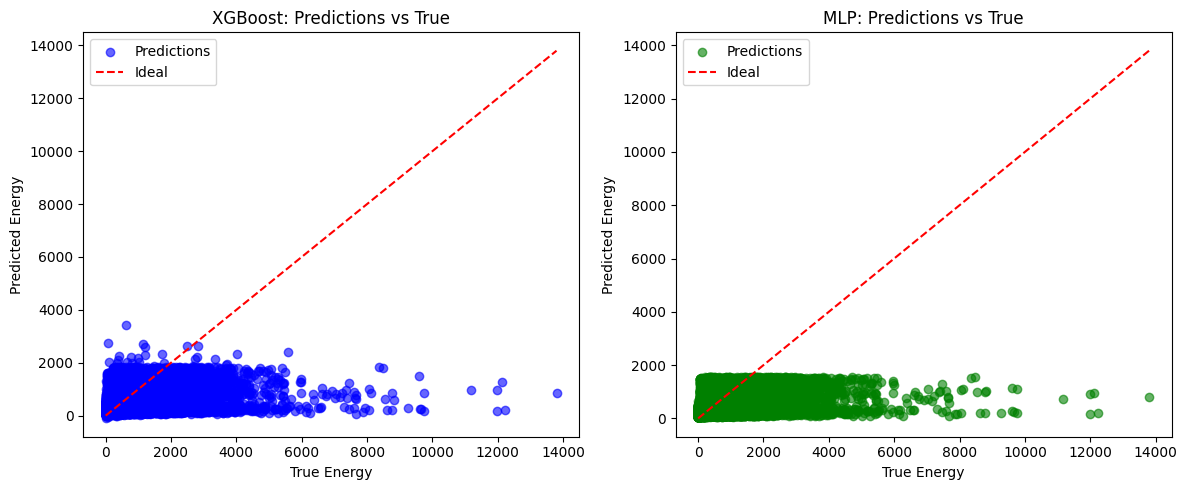

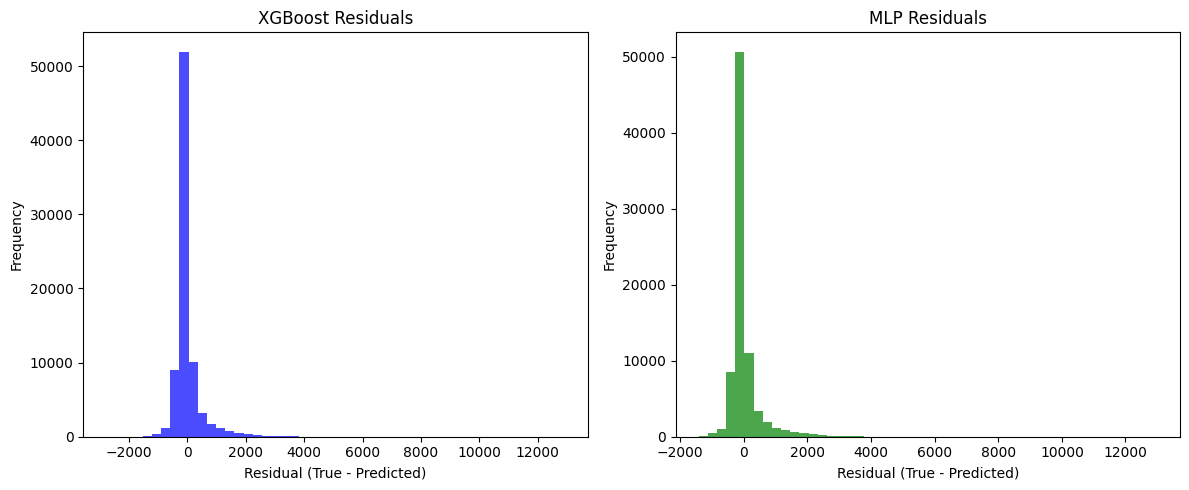

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_ml_predictions(y_test_orig, y_pred_xgb_orig, y_pred_mlp_orig):
    plt.figure(figsize=(12, 5))

    #XGBoost Predictions vs True
    plt.subplot(1, 2, 1)
    plt.scatter(y_test_orig, y_pred_xgb_orig, alpha=0.6, label="Predictions", color="blue")
    plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', label="Ideal")
    plt.xlabel("True Energy")
    plt.ylabel("Predicted Energy")
    plt.title("XGBoost: Predictions vs True")
    plt.legend()

    #MLP Predictions vs True
    plt.subplot(1, 2, 2)
    plt.scatter(y_test_orig, y_pred_mlp_orig, alpha=0.6, label="Predictions", color="green")
    plt.plot([y_test_orig.min(), y_test_orig.max()], [y_test_orig.min(), y_test_orig.max()], 'r--', label="Ideal")
    plt.xlabel("True Energy")
    plt.ylabel("Predicted Energy")
    plt.title("MLP: Predictions vs True")
    plt.legend()

    plt.tight_layout()
    plt.show()

#Function to visualize Residuals (Error Distribution)
def visualize_ml_residuals(y_test_orig, y_pred_xgb_orig, y_pred_mlp_orig):
    plt.figure(figsize=(12, 5))

    #XGBoost Residuals
    residuals_xgb = y_test_orig - y_pred_xgb_orig
    plt.subplot(1, 2, 1)
    plt.hist(residuals_xgb.flatten(), bins=50, alpha=0.7, color="blue")
    plt.xlabel("Residual (True - Predicted)")
    plt.ylabel("Frequency")
    plt.title("XGBoost Residuals")

    #MLP Residuals
    residuals_mlp = y_test_orig - y_pred_mlp_orig
    plt.subplot(1, 2, 2)
    plt.hist(residuals_mlp.flatten(), bins=50, alpha=0.7, color="green")
    plt.xlabel("Residual (True - Predicted)")
    plt.ylabel("Frequency")
    plt.title("MLP Residuals")

    plt.tight_layout()
    plt.show()

#Run the visualization functions
visualize_ml_predictions(y_test_orig, y_pred_xgb_orig, y_pred_mlp_orig)
visualize_ml_residuals(y_test_orig, y_pred_xgb_orig, y_pred_mlp_orig)


## NEW NEW NEW

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import torch
import torch.nn as nn
import torch.optim as optim

# Assume df = your full node-level dataset
df = nodes_df.copy()

# ──────────────────────────────────────
# 1. Aggregate cluster-level features
# ──────────────────────────────────────
# Use mean, std, min, max of node-level features in each cluster
df["type"] = df["type"].map({"seed": 1, "neighbor": 0})

agg_features = df.groupby("clusterId")[["row", "column", "MCID", "type"]].agg(['mean', 'std', 'min', 'max']).reset_index()

# Flatten column names
agg_features.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in agg_features.columns]

# ──────────────────────────────────────
# 2. Create cluster-level target
# ──────────────────────────────────────
cluster_target = df.groupby("clusterId")["energy"].sum().reset_index(name="cluster_energy")

# ──────────────────────────────────────
# 3. Merge features and target
# ──────────────────────────────────────
data = pd.merge(agg_features, cluster_target, left_on="clusterId_", right_on="clusterId")
data.drop(columns=["clusterId", "clusterId_"], inplace=True)

# ──────────────────────────────────────
# 4. Prepare features and target
# ──────────────────────────────────────
X = data.drop(columns=["cluster_energy"])
y = data[["cluster_energy"]]

# Normalize
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)


In [30]:
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train.ravel())

# Predict
y_pred = xgb_model.predict(X_test)
y_pred_orig = scaler_y.inverse_transform(y_pred.reshape(-1, 1))
y_test_orig = scaler_y.inverse_transform(y_test)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae = mean_absolute_error(y_test_orig, y_pred_orig)
rel_error = (rmse / np.mean(np.abs(y_test_orig))) * 100

print(f"📊 XGBoost - RMSE: {rmse:.2f}, MAE: {mae:.2f}, Relative Error: {rel_error:.2f}%")


📊 XGBoost - RMSE: 2074.19, MAE: 1323.03, Relative Error: 61.51%


In [24]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import numpy as np

def visualize_xgboost_performance(y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)

    plt.figure(figsize=(12, 5))

    # Scatter: Predictions vs Ground Truth
    plt.subplot(1, 2, 1)
    plt.scatter(y_true, y_pred, alpha=0.6, color="blue", label="Predicted")
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', label="Ideal")
    plt.xlabel("True Energy")
    plt.ylabel("Predicted Energy")
    plt.title("XGBoost: Predictions vs True")
    plt.legend()

    # Histogram: Residuals
    residuals = y_true - y_pred
    plt.subplot(1, 2, 2)
    plt.hist(residuals, bins=50, alpha=0.7, color="blue")
    plt.xlabel("Residual (True - Predicted)")
    plt.ylabel("Frequency")
    plt.title("XGBoost Residuals")

    plt.tight_layout()
    plt.show()



In [33]:
print("y_test_orig shape:", y_test_orig.shape)
print("y_pred_xgb_orig shape:", y_pred_xgb_orig.shape)





y_test_orig shape: (7101, 1)
y_pred_xgb_orig shape: (81358, 1)


In [21]:
print("X.shape:", X.shape)
print("y.shape:", y.shape)


X.shape: (35503, 16)
y.shape: (35503, 1)


In [22]:
print("X_test.shape:", X_test.shape)
print("y_test.shape:", y_test.shape)

X_test.shape: (7101, 16)
y_test.shape: (7101, 1)


In [23]:
y_pred = xgb_model.predict(X_test)
print("y_pred shape:", y_pred.shape)

y_pred shape: (7101,)


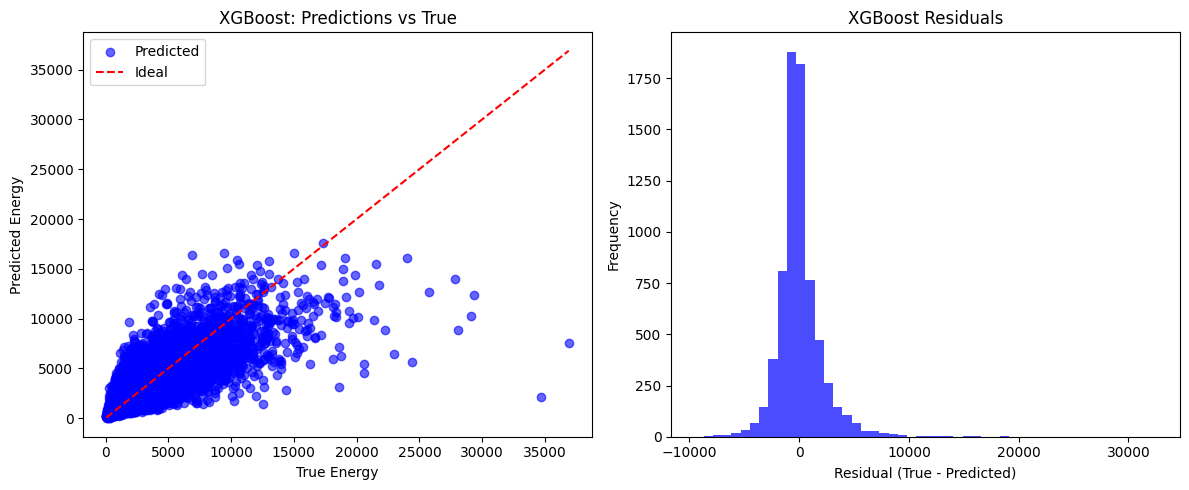

In [34]:
visualize_xgboost_performance(y_test_orig, y_pred_orig)



In [12]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
mlp = MLP(input_dim, hidden_dim=64, out_dim=1)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mlp = mlp.to(device)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

optimizer = optim.Adam(mlp.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

for epoch in range(300):
    mlp.train()
    optimizer.zero_grad()
    out = mlp(X_train_tensor)
    loss = loss_fn(out, y_train_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

# Eval
mlp.eval()
with torch.no_grad():
    preds = mlp(X_test_tensor).cpu().numpy()
    preds_orig = scaler_y.inverse_transform(preds)
    y_test_orig = scaler_y.inverse_transform(y_test)

rmse_mlp = np.sqrt(mean_squared_error(y_test_orig, preds_orig))
mae_mlp = mean_absolute_error(y_test_orig, preds_orig)
rel_error_mlp = (rmse_mlp / np.mean(np.abs(y_test_orig))) * 100

print(f"🤖 MLP - RMSE: {rmse_mlp:.2f}, MAE: {mae_mlp:.2f}, Relative Error: {rel_error_mlp:.2f}%")


Epoch 0, Loss: nan
Epoch 50, Loss: nan
Epoch 100, Loss: nan
Epoch 150, Loss: nan
Epoch 200, Loss: nan
Epoch 250, Loss: nan


ValueError: Input contains NaN.